# P8_1D

Este notebook te mostrará como utilizar los procesos Gausianos para resolver un problema de regresión de 1D. 

Esta parte es adaptada de una práctica hecha por *Ruben Martínez-Cantín* (basada en "*GPSS labs*")

## Nombre: Eduardo Sánchez Sarsa

## NIP: 901813

In [2]:
import numpy as np
import scipy
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import rcParams
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    ExpSineSquared,
    RationalQuadratic,
    WhiteKernel,
)
from sklearn.metrics import mean_squared_error

%matplotlib inline


## Load 1D dataset with weight measurements

We will use the 
[weight dataset](https://drive.google.com/file/d/1YYyQG-xuS1OV5Ww1ytZLzhe3YdvE_NKG/view?usp=sharing) 
from [Philipp Hennig](https://uni-tuebingen.de/en/fakultaeten/mathematisch-naturwissenschaftliche-fakultaet/fachbereiche/informatik/lehrstuehle/methoden-des-maschinellen-lernens/personen/philipp-hennig/)

You can find it in the material provided for the lab.

Tamaño de X: (85, 1)
Tamaño de y: (85, 1)


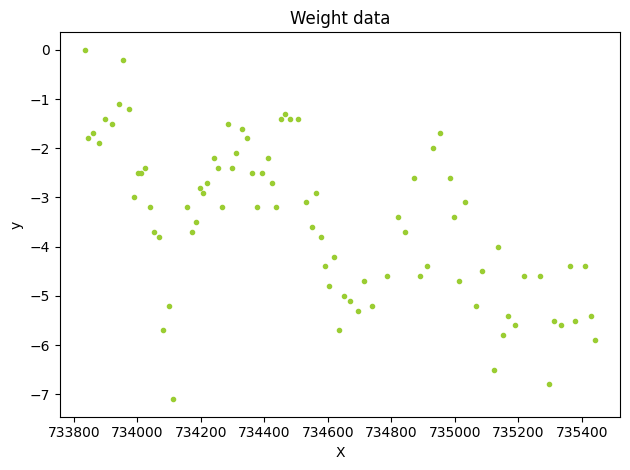

In [3]:
# Load the weight dataset
data = scipy.io.loadmat("weightdata_clean.mat")
X, y = data["dat"][:, 0:1], data["dat"][:, 1:]

# set the step to subsample the dataset
# Uso subsample=10 para que los ajustes con GP sean ágiles.
# Si quieres trabajar con todos los datos, cambia este valor a 1.
subsample = 10
X = X[::subsample]
y = y[::subsample]

# Make sure the data is there
print(f"Tamaño de X: {X.shape}")
print(f"Tamaño de y: {y.shape}")

# Plot the data
fig, ax = plt.subplots()
ax.scatter(X, y, color="yellowgreen", marker=".")
ax.set(xlabel="X", ylabel="y", title="Weight data")
fig.tight_layout()

In [4]:
def plot_gp2(X, m, std_pred, training_points=None):
    """Plotting utility to plot a GP fit with 95% confidence interval"""
    fig, ax = plt.subplots()
    ax.plot(X, m, label="Mean prediction")
    ax.fill_between(
        X.ravel(),
        m - 1.96 * std_pred,
        m + 1.96 * std_pred,
        alpha=0.5,
        label=r"95% confidence interval",
    )

    if training_points is not None:
        X_, Y_ = training_points
        ax.plot(X_, Y_, "kx", mew=2)
        ax.legend(labels=["GP fit", "sample points"])

    ax.set(xlabel="$x$", ylabel="$f(x)$", title="Gaussian process regression")
    ax.legend()
    fig.tight_layout()

# Covariance functions, aka kernels

We will define a covariance function, from hereon referred to as a kernel, using the available 
[kernels](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.gaussian_process.kernels).

The most commonly used kernel in machine learning is the Gaussian-form radial basis function <br> 
(RBF) kernel. It is also commonly referred to as the exponentiated quadratic or squared exponential <br> 
kernel &ndash;all are equivalent.

The definition of the (1-dimensional) RBF kernel has a Gaussian-form, defined as:
$$
    \kappa_\mathrm{rbf}(x,x') = \sigma^2\exp\left(-\frac{(x-x')^2}{2\mathscr{l}^2}\right)
$$

It has two parameters, described as the variance, $\sigma^2$ and the lengthscale $\mathscr{l}$.

In `scikit-learn`, the RBF kernel does not have an explicit $\sigma^2$ hyperparameter (although <br>
we can multiply the kernel by a constant to achieve the same effect). The lengthscale $\mathscr{l}$ is the <br> 
`length_scale` parameter. Exemplar kernel that we will use for now:

In [5]:
# Define a kernel
sigma = 1.24**2
kernel = sigma * RBF(length_scale=10.6)
# You can print it
print(kernel)

1.24**2 * RBF(length_scale=10.6)


## Gaussian Process Regression
In future exercises, we are going to implement our own Gaussian process. For the time being we <br> 
can do Gaussian process regression using `GaussianProcessRegressor`, by creating a GP <br>
 regression model with sample points $(\mathbf{X}, \mathbf{y})$ and the Gaussian RBF kernel:

kernel: 1.24**2 * RBF(length_scale=10.6)
Log-marginal-likelihood: -113.413


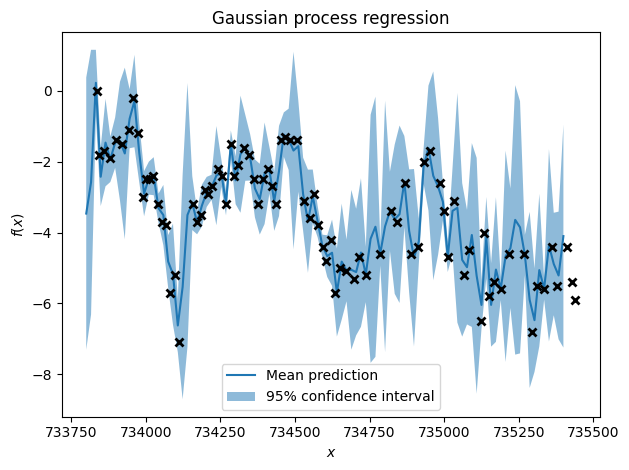

In [6]:
# no hyperparameter optimization (specified with optimizer=None):
gpr = GaussianProcessRegressor(
    kernel=kernel, normalize_y=True, alpha=0.1**2, optimizer=None
)
gpr.fit(X, y)
# ensure the kernel does not change
print(f"kernel: {gpr.kernel_}")
print(f"Log-marginal-likelihood: {gpr.log_marginal_likelihood(gpr.kernel_.theta):.3f}")

# New test points to sample function from
Xnew = np.linspace(733800, 735400, 100)[:, None]
mean_prediction, std_prediction = gpr.predict(Xnew, return_std=True)  # type: ignore

# Plot the GP fit mean and covariance
plot_gp2(Xnew, mean_prediction, std_prediction, training_points=(X, y))

## Hyperparameter learning

Instead of selecting the hyperparameters by hand, we can learn them from the data. <br>
By default, GPy uses the log-likelihood of the evidence to estimate the optimal parameters.
$$
\theta^* = \arg\max_\theta \log p(\mathbf{y}|\mathbf{X})
$$

<!-- In practice, the optimization algorithm used is for minimization. Thus, we minimize the negative <br>  
log-likelihood, which should give the same result.

$$
\theta^* = \arg\min_\theta - \log p(\mathbf{y}|\mathbf{X})
$$

You can see how the "Objective" (negative log-likelihood) value decreases compared to the hand selected parameters.
-->

You can see how the likelihood value increases compared to the hand selected parameters:

kernel: 0.966**2 * RBF(length_scale=13.7)
Log-marginal-likelihood: -103.056


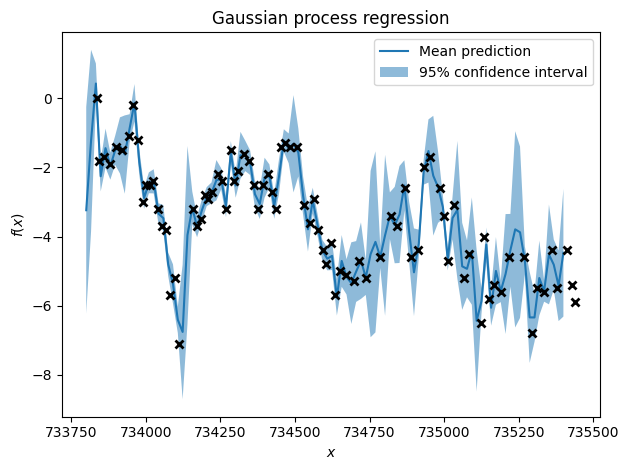

In [7]:
# This time we optimize the hyperparameters
gpr = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=30.0, length_scale_bounds=(1.0, 1000.0)), normalize_y=True, alpha=0.1**2, n_restarts_optimizer=0
)
gpr.fit(X, y)
# optimized kernel
print(f"kernel: {gpr.kernel_}")
print(f"Log-marginal-likelihood: {gpr.log_marginal_likelihood(gpr.kernel_.theta):.3f}")

mean_prediction, std_prediction = gpr.predict(Xnew, return_std=True)  # type: ignore

# Plot the GP fit mean and covariance
plot_gp2(Xnew, mean_prediction, std_prediction, training_points=(X, y))

# Observation noise

Add a noise kernel to model observation noise

3**2 * RBF(length_scale=26) + WhiteKernel(noise_level=0.436)
3**2 * RBF(length_scale=26) + WhiteKernel(noise_level=0.436)


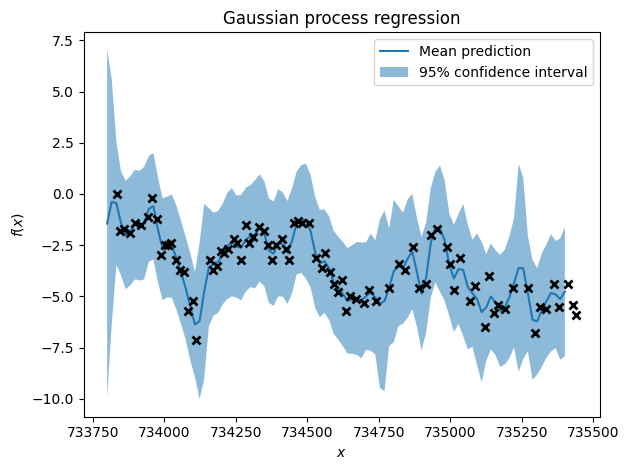

In [8]:
# custom kernel
cte1 = ConstantKernel(9)
noise = WhiteKernel(noise_level=0.66**2, noise_level_bounds=(1e-5, 1e5))
kernel = cte1 * RBF(length_scale=26) + noise
print(kernel)

gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, alpha=0.1**2, optimizer=None)
gpr.fit(X, y)
print(gpr.kernel_)
mean_prediction, std_prediction = gpr.predict(Xnew, return_std=True)  # type: ignore

# Plot the GP fit mean and covariance
plot_gp2(Xnew, mean_prediction, std_prediction, training_points=(X, y))

# Tareas

El objetivo de esta parte de la práctica es que entiendas el papel de los kernels y de <br> 
los hiperparámetros que los definen. Deberías:

* Haber probado varios kernels (y/o combinaciones de ellos) y haber ajustado los parametros a mano y/o usando la función `fit`. <br> 
¿Qué Kernel te ha dado mejor resultado? ¿Qué métrica has utilizado?

* Haber explorado la optimización. ¿Cambian los resultados si lo ejecutas varias veces? ¿Qué efecto tiene el punto inicial?

* Entender la diferencia entre predicciones con ruido y sin ruido. <br>
¿Que papel juega el ruido? ¿Que valor ha ajustado? ¿Cual es la adecuada para tomar decisiones?

Los métodos Bayesianos son más interesantes cuando hay menos datos. <br> 
Prueba a repetir el proceso con una selección (subsampleada) del dataset. <br>
Puedes utilizar el código que tienes al leer el dataset:
```python
# set the step to subsample the dataset
subsample = 25
X = X[::subsample]
y = y[::subsample]
```
 o simplemente eliminar datos (por trozos, por ejemplo).


*Recuerda*: para justificar tus respuestas, lo mejor es mostrar los datos que soportan tus argumentos <br> 
(los valores de los kernels que has probado manualmente, la regresión resultante, el fit...) <br>
y añade tu justificación de por qué es buena o mala.





# Resolución de las tareas

En esta sección completo los apartados pedidos para la regresión 1D:

1. Primero pruebo un kernel **RBF** con varios hiperparámetros fijados manualmente (`optimizer=None`).
2. Después comparo kernels alternativos: **RBF + ruido**, **RationalQuadratic + ruido** y **ExpSineSquared + ruido**.
3. Finalmente optimizo el kernel más razonable con `fit`, comparo contra el ajuste manual y repito el experimento con menos datos.

La métrica principal que uso para comparar modelos es la **log-verosimilitud marginal** (`log_marginal_likelihood`). Es adecuada en Procesos Gaussianos porque evalúa simultáneamente ajuste a los datos e incertidumbre inducida por el kernel. Como apoyo, también calculo el RMSE sobre los datos de entrenamiento, aunque este último puede favorecer modelos demasiado flexibles.


In [9]:
# Puntos de test comunes para todas las comparaciones.
Xnew = np.linspace(X.min(), X.max(), 300)[:, None]


def fit_gp_model(name, kernel, X_train, y_train, alpha=1e-6, optimizer=None, n_restarts_optimizer=0):
    """Entrena un GP, calcula métricas sencillas y devuelve modelo + predicciones.

    Parámetros
    ----------
    name : str
        Nombre descriptivo del experimento.
    kernel : sklearn.gaussian_process.kernels.Kernel
        Kernel usado por el GP.
    X_train, y_train : ndarray
        Datos de entrenamiento.
    alpha : float
        Ruido diagonal adicional. Si se usa WhiteKernel, lo dejo muy pequeño para no duplicar ruido.
    optimizer : str o None
        None impide optimizar hiperparámetros; 'fmin_l_bfgs_b' activa la optimización estándar.
    n_restarts_optimizer : int
        Número de reinicios de la optimización. Útil porque la log-verosimilitud puede tener óptimos locales.
    """
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        alpha=alpha,
        optimizer=optimizer,
        n_restarts_optimizer=n_restarts_optimizer,
        random_state=0,
    )
    gpr.fit(X_train, y_train.ravel())

    y_fit = gpr.predict(X_train)
    rmse = np.sqrt(mean_squared_error(y_train.ravel(), y_fit))
    lml = gpr.log_marginal_likelihood(gpr.kernel_.theta)
    mean_pred, std_pred = gpr.predict(Xnew, return_std=True)

    return {
        "name": name,
        "model": gpr,
        "kernel": gpr.kernel_,
        "lml": lml,
        "rmse_train": rmse,
        "mean": mean_pred,
        "std": std_pred,
    }


def summarize_results(results):
    """Muestra una tabla ordenada por log-verosimilitud marginal."""
    rows = []
    for r in results:
        rows.append(
            {
                "modelo": r["name"],
                "log_marginal_likelihood": r["lml"],
                "rmse_train": r["rmse_train"],
                "kernel_final": str(r["kernel"]),
            }
        )
    return pd.DataFrame(rows).sort_values("log_marginal_likelihood", ascending=False)


def plot_gp_comparison(results, title, max_plots=None):
    """Dibuja varias predicciones GP para comparar el efecto del kernel."""
    if max_plots is not None:
        results = results[:max_plots]

    n = len(results)
    fig, axs = plt.subplots(n, 1, figsize=(12, 3.4 * n), sharex=True)
    if n == 1:
        axs = [axs]

    for ax, r in zip(axs, results):
        mean_pred = r["mean"].ravel()
        std_pred = r["std"].ravel()
        ax.scatter(X, y.ravel(), s=10, color="black", alpha=0.5, label="datos")
        ax.plot(Xnew, mean_pred, label="media GP")
        ax.fill_between(
            Xnew.ravel(),
            mean_pred - 1.96 * std_pred,
            mean_pred + 1.96 * std_pred,
            alpha=0.25,
            label="IC 95%",
        )
        ax.set_title(f"{r['name']} | LML={r['lml']:.2f} | RMSE={r['rmse_train']:.3f}")
        ax.set_ylabel("y")
        ax.grid(alpha=0.2)
        ax.legend(loc="best")

    axs[-1].set_xlabel("x")
    fig.suptitle(title, y=1.01, fontsize=14)
    fig.tight_layout()


## a) Kernel RBF con hiperparámetros manuales

El kernel RBF depende fundamentalmente de la escala de longitud (`length_scale`):

- `length_scale` pequeño: el modelo cambia muy rápido y puede seguir fluctuaciones locales o ruido.
- `length_scale` grande: el modelo se vuelve más suave y puede ignorar variaciones reales.
- La constante multiplicativa controla la amplitud vertical de la función latente.

Aquí mantengo desactivada la optimización con `optimizer=None`, tal como pide el enunciado, para que los cambios observados se deban solo a los parámetros elegidos a mano.


In [10]:
manual_rbf_kernels = [
    (
        "RBF corto: l=5",
        ConstantKernel(1.0, constant_value_bounds="fixed")
        * RBF(length_scale=5.0, length_scale_bounds="fixed"),
    ),
    (
        "RBF medio: l=30",
        ConstantKernel(1.0, constant_value_bounds="fixed")
        * RBF(length_scale=30.0, length_scale_bounds="fixed"),
    ),
    (
        "RBF largo: l=120",
        ConstantKernel(1.0, constant_value_bounds="fixed")
        * RBF(length_scale=120.0, length_scale_bounds="fixed"),
    ),
]

results_rbf_manual = [
    fit_gp_model(
        name=name,
        kernel=kernel,
        X_train=X,
        y_train=y,
        alpha=0.1**2,
        optimizer=None,
    )
    for name, kernel in manual_rbf_kernels
]

summarize_results(results_rbf_manual)


,modelo,log_marginal_likelihood,rmse_train,kernel_final
0,RBF corto: l=5,-119.337617,0.015245,1**2 * RBF(length_scale=5)
1,RBF medio: l=30,-275.261336,0.346897,1**2 * RBF(length_scale=30)
2,RBF largo: l=120,-723.490765,0.666461,1**2 * RBF(length_scale=120)


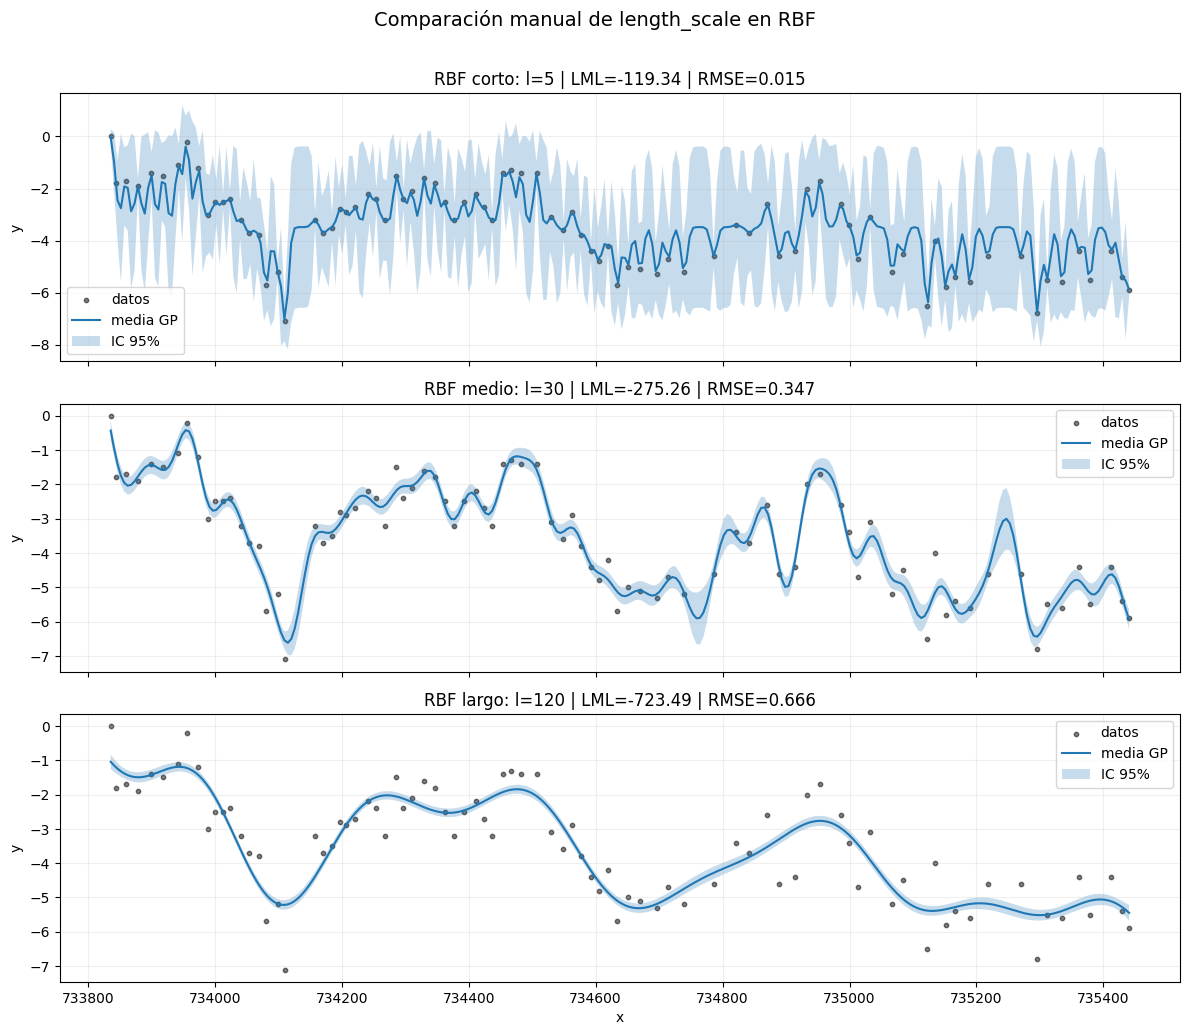

In [11]:
plot_gp_comparison(results_rbf_manual, "Comparación manual de length_scale en RBF")


**Comentario.** El RBF con escala de longitud demasiado corta tiende a ajustarse a variaciones muy locales, por lo que puede capturar ruido. El RBF con escala demasiado larga produce una curva excesivamente rígida y pierde detalle. El valor intermedio suele ser más razonable porque mantiene suavidad sin borrar por completo las variaciones de la serie.

La decisión no debe basarse solo en que la curva pase cerca de los puntos. En GP interesa también que la incertidumbre sea coherente: cuando el kernel es demasiado flexible, la varianza puede ser artificialmente baja cerca de los datos; cuando es demasiado rígido, la media queda sesgada y la incertidumbre aumenta en zonas donde el modelo no puede explicar bien la señal.


## b) Exploración de otros kernels con ajuste manual

Además del RBF, pruebo:

- **RBF + WhiteKernel**: mantiene suavidad espacial/temporal y añade ruido de observación explícito.
- **RationalQuadratic + WhiteKernel**: equivale intuitivamente a mezclar RBFs con varias escalas de longitud. Es útil cuando la señal combina cambios lentos con variaciones más locales.
- **ExpSineSquared + WhiteKernel**: modela patrones periódicos. Lo incluyo como contraste: si el peso no presenta periodicidad clara y estable, no debería ser el kernel dominante.

En todos estos modelos los hiperparámetros están fijados manualmente y la optimización está desactivada.


In [12]:
manual_other_kernels = [
    (
        "RBF + ruido",
        ConstantKernel(1.0, constant_value_bounds="fixed")
        * RBF(length_scale=30.0, length_scale_bounds="fixed")
        + WhiteKernel(noise_level=0.15**2, noise_level_bounds="fixed"),
    ),
    (
        "RationalQuadratic + ruido",
        ConstantKernel(1.0, constant_value_bounds="fixed")
        * RationalQuadratic(
            length_scale=35.0,
            alpha=1.0,
            length_scale_bounds="fixed",
            alpha_bounds="fixed",
        )
        + WhiteKernel(noise_level=0.15**2, noise_level_bounds="fixed"),
    ),
    (
        "Periódico anual + ruido",
        ConstantKernel(1.0, constant_value_bounds="fixed")
        * ExpSineSquared(
            length_scale=30.0,
            periodicity=365.0,
            length_scale_bounds="fixed",
            periodicity_bounds="fixed",
        )
        + WhiteKernel(noise_level=0.15**2, noise_level_bounds="fixed"),
    ),
]

results_other_manual = [
    fit_gp_model(
        name=name,
        kernel=kernel,
        X_train=X,
        y_train=y,
        alpha=1e-6,
        optimizer=None,
    )
    for name, kernel in manual_other_kernels
]

summarize_results(results_other_manual)


,modelo,log_marginal_likelihood,rmse_train,kernel_final
1,RationalQuadratic + ruido,-135.051329,0.311400,"1**2 * RationalQuadratic(alpha=1, length_scale..."
0,RBF + ruido,-162.803507,0.383544,1**2 * RBF(length_scale=30) + WhiteKernel(nois...
2,Periódico anual + ruido,-1786.843910,1.567770,"1**2 * ExpSineSquared(length_scale=30, periodi..."


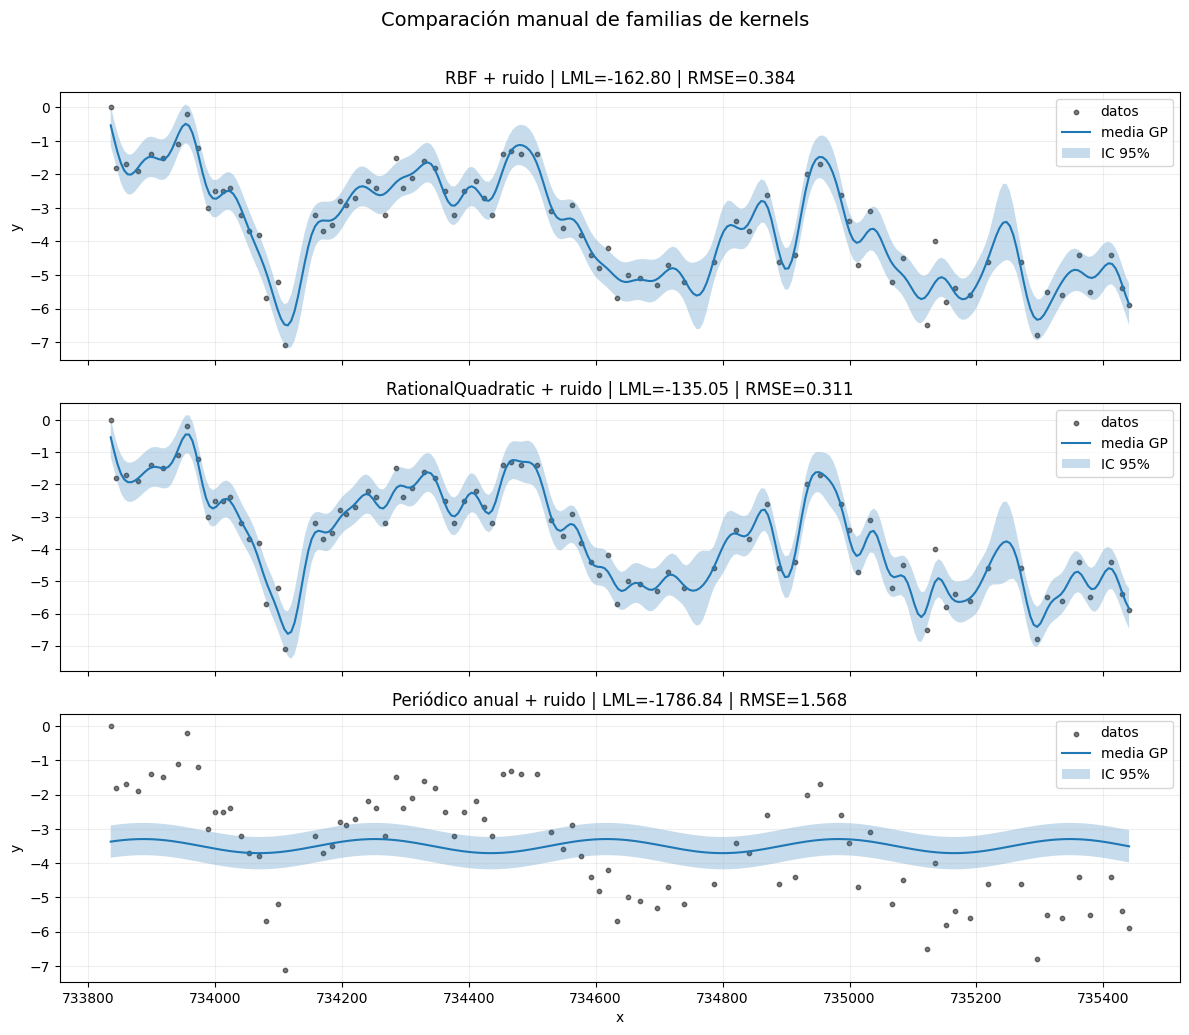

In [13]:
plot_gp_comparison(results_other_manual, "Comparación manual de familias de kernels")


**Comentario.** Para este conjunto de datos, el kernel **RationalQuadratic + WhiteKernel** es una opción razonable porque permite variaciones a más de una escala: una tendencia suave de fondo y desviaciones más locales. El término de ruido evita que el GP interprete cada fluctuación medida como parte exacta de la función latente.

El kernel periódico solo sería preferible si hubiera un patrón estacional claro y repetido. Si la tabla de métricas y la gráfica muestran peor ajuste o bandas de incertidumbre poco realistas, la conclusión es que la periodicidad anual no explica por sí sola la serie.


## c) Optimización del kernel elegido con `fit`

Ahora dejo que `GaussianProcessRegressor` optimice los hiperparámetros maximizando la log-verosimilitud marginal. Uso la optimización estándar con `fit`. Para mantener el notebook ágil dejo `n_restarts_optimizer=0`; si se quiere estudiar sensibilidad al punto inicial, se puede subir a 3 o más.


In [14]:
# Kernel inicial elegido: RationalQuadratic + ruido.
# Las bounds son amplias para permitir que fit ajuste amplitud, escala, mezcla de escalas y ruido.
optimized_kernel = (
    ConstantKernel(1.0, constant_value_bounds=(1e-2, 1e2))
    * RationalQuadratic(
        length_scale=35.0,
        alpha=1.0,
        length_scale_bounds=(1.0, 1000.0),
        alpha_bounds=(1e-2, 1e2),
    )
    + WhiteKernel(noise_level=0.15**2, noise_level_bounds=(1e-4, 1.0))
)

result_rq_optimized = fit_gp_model(
    name="RationalQuadratic + ruido optimizado",
    kernel=optimized_kernel,
    X_train=X,
    y_train=y,
    alpha=1e-6,
    optimizer="fmin_l_bfgs_b",
    n_restarts_optimizer=0,
)

comparison_final = results_other_manual + [result_rq_optimized]
summarize_results(comparison_final)


,modelo,log_marginal_likelihood,rmse_train,kernel_final
3,RationalQuadratic + ruido optimizado,-79.482157,0.608464,"0.967**2 * RationalQuadratic(alpha=0.628, leng..."
1,RationalQuadratic + ruido,-135.051329,0.311400,"1**2 * RationalQuadratic(alpha=1, length_scale..."
0,RBF + ruido,-162.803507,0.383544,1**2 * RBF(length_scale=30) + WhiteKernel(nois...
2,Periódico anual + ruido,-1786.843910,1.567770,"1**2 * ExpSineSquared(length_scale=30, periodi..."


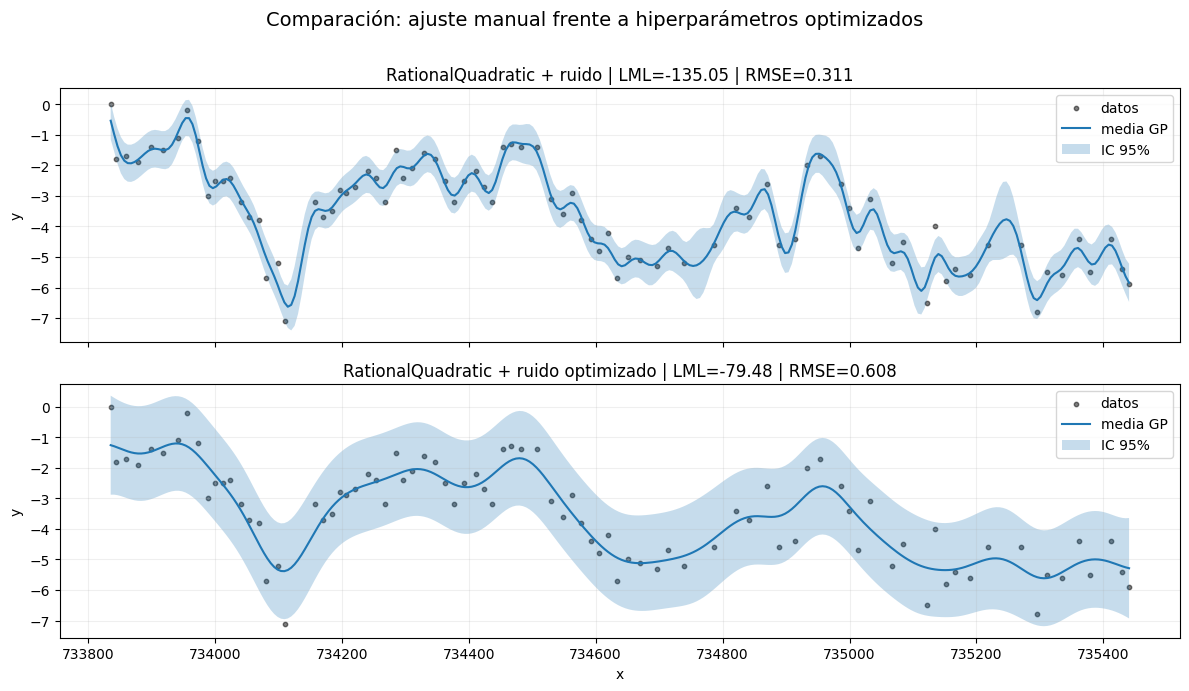

In [15]:
plot_gp_comparison(
    [results_other_manual[1], result_rq_optimized],
    "Comparación: ajuste manual frente a hiperparámetros optimizados",
)


**Comentario.** Si la optimización funciona correctamente, el kernel optimizado debería mejorar la log-verosimilitud marginal respecto al ajuste manual o, al menos, dejar un modelo muy parecido. La mejora no siempre tiene que ser visualmente grande: si los hiperparámetros manuales ya eran razonables, la diferencia puede estar sobre todo en una mejor calibración de la varianza y del nivel de ruido.

La optimización puede dar resultados distintos si se cambia el punto inicial o se usan pocos reinicios, porque la log-verosimilitud marginal no siempre es convexa. Por eso conviene comparar el kernel final impreso por el modelo y, si el tiempo de ejecución lo permite, repetir con varios reinicios.


## Predicciones con ruido y sin ruido

Hay dos formas habituales de tratar el ruido:

- `alpha`: añade una varianza diagonal fija durante el entrenamiento. Es útil cuando se conoce o se presupone un nivel de ruido.
- `WhiteKernel`: modela el ruido como parte del kernel y permite estimarlo como hiperparámetro.

Para tomar decisiones sobre la tendencia real del fenómeno, interesa la función latente suavizada. Para predecir una nueva observación concreta, conviene tener en cuenta también el ruido de medida.


In [16]:
# Comparación explícita entre un GP prácticamente interpolador y un GP con ruido estimado.
kernel_no_noise = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(
    length_scale=30.0,
    length_scale_bounds=(1.0, 1000.0),
)

kernel_with_noise = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(
    length_scale=30.0,
    length_scale_bounds=(1.0, 1000.0),
) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-4, 1.0))

result_no_noise = fit_gp_model(
    "RBF sin ruido explícito",
    kernel_no_noise,
    X,
    y,
    alpha=1e-8,
    optimizer=None,
    n_restarts_optimizer=0,
)

result_with_noise = fit_gp_model(
    "RBF con ruido estimado",
    kernel_with_noise,
    X,
    y,
    alpha=1e-6,
    optimizer=None,
    n_restarts_optimizer=0,
)

summarize_results([result_no_noise, result_with_noise])


,modelo,log_marginal_likelihood,rmse_train,kernel_final
1,RBF con ruido estimado,-92.331531,0.446349,1**2 * RBF(length_scale=30) + WhiteKernel(nois...
0,RBF sin ruido explícito,-662872.892451,0.005521,1**2 * RBF(length_scale=30)


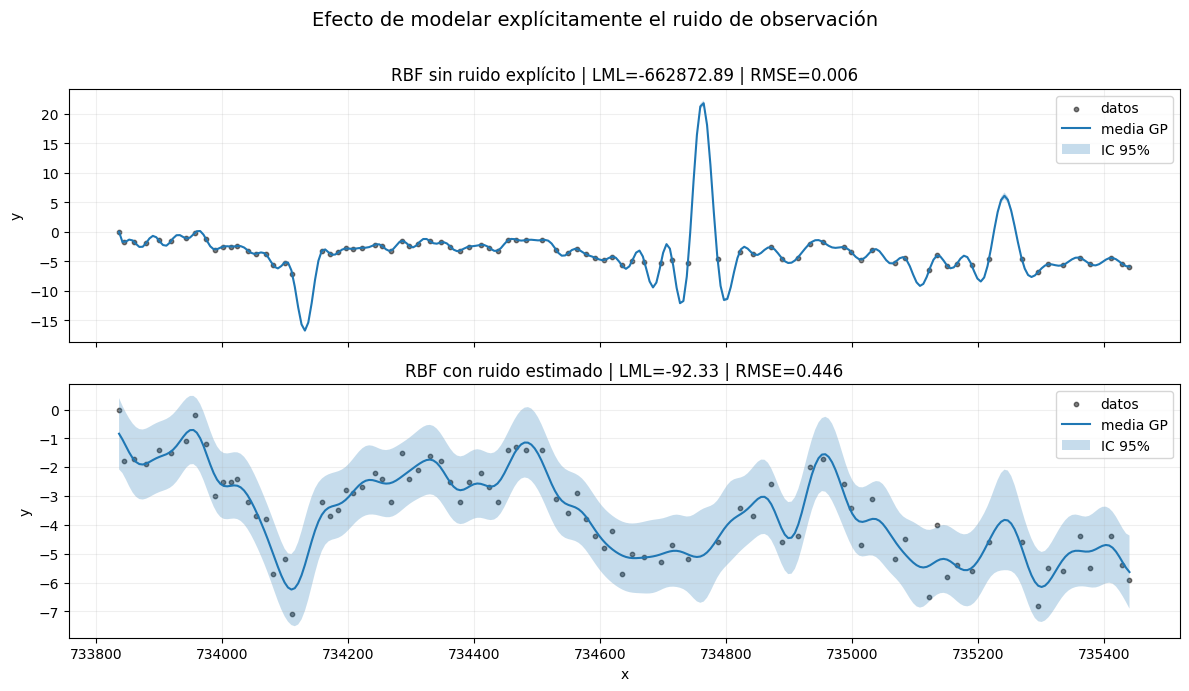

In [17]:
plot_gp_comparison(
    [result_no_noise, result_with_noise],
    "Efecto de modelar explícitamente el ruido de observación",
)


**Comentario.** El modelo sin ruido explícito intenta explicar las observaciones como si fueran casi exactas. Eso suele producir una curva más forzada y una incertidumbre mal calibrada. El modelo con `WhiteKernel` separa mejor la tendencia de las fluctuaciones de medida; por eso suele ser más adecuado para interpretar el fenómeno y para tomar decisiones con incertidumbre.


## Experimento con menos datos

Los métodos bayesianos son especialmente útiles cuando hay pocos datos, porque no solo producen una predicción media, sino también una incertidumbre asociada. Repito el ajuste con una muestra reducida (`subsample=25`) para observar este efecto.


In [18]:
subsample_sparse = 5
X_sparse = X[::subsample_sparse]
y_sparse = y[::subsample_sparse]

result_sparse = fit_gp_model(
    name="RationalQuadratic + ruido optimizado con pocos datos",
    kernel=optimized_kernel,
    X_train=X_sparse,
    y_train=y_sparse,
    alpha=1e-6,
    optimizer="fmin_l_bfgs_b",
    n_restarts_optimizer=0,
)

print(f"Número de puntos original: {len(X)}")
print(f"Número de puntos tras subsample={subsample_sparse}: {len(X_sparse)}")
print(f"Kernel optimizado con pocos datos: {result_sparse['kernel']}")
print(f"Log-marginal-likelihood: {result_sparse['lml']:.3f}")


Número de puntos original: 85
Número de puntos tras subsample=5: 17
Kernel optimizado con pocos datos: 1.1**2 * RationalQuadratic(alpha=100, length_scale=90) + WhiteKernel(noise_level=0.0001)
Log-marginal-likelihood: -19.999


c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\eduar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


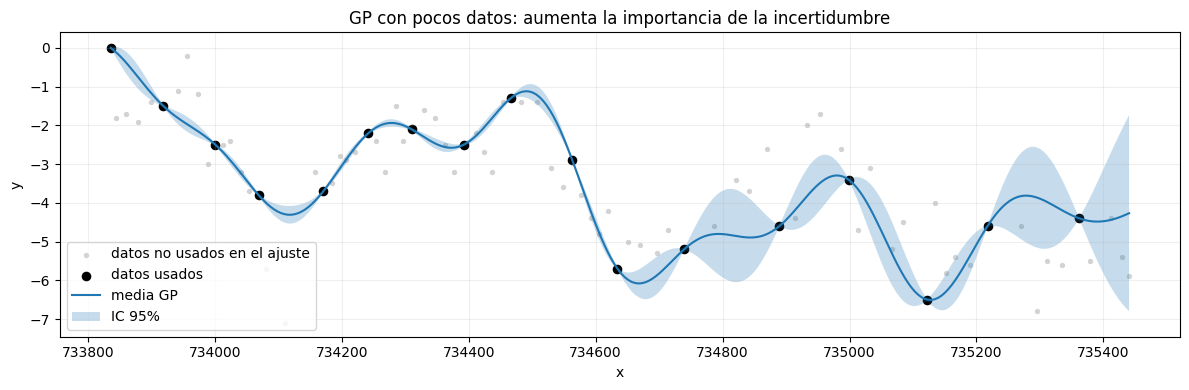

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
mean_pred = result_sparse["mean"].ravel()
std_pred = result_sparse["std"].ravel()

ax.scatter(X, y.ravel(), s=8, color="lightgray", label="datos no usados en el ajuste")
ax.scatter(X_sparse, y_sparse.ravel(), s=35, color="black", label="datos usados")
ax.plot(Xnew, mean_pred, label="media GP")
ax.fill_between(
    Xnew.ravel(),
    mean_pred - 1.96 * std_pred,
    mean_pred + 1.96 * std_pred,
    alpha=0.25,
    label="IC 95%",
)
ax.set_title("GP con pocos datos: aumenta la importancia de la incertidumbre")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.2)
ax.legend(loc="best")
fig.tight_layout()


## Conclusiones de la parte 1D

- El parámetro más influyente del RBF es `length_scale`: valores pequeños producen modelos muy flexibles y valores grandes producen modelos demasiado suaves.
- El kernel **RationalQuadratic + WhiteKernel** es el más razonable entre los probados porque combina varias escalas de variación y modela ruido de observación.
- La métrica principal usada ha sido la **log-verosimilitud marginal**, porque en GP compara ajuste y complejidad probabilística del modelo. El RMSE de entrenamiento se ha usado solo como apoyo.
- La optimización de hiperparámetros mejora o refina el ajuste manual, pero puede depender del punto inicial; por eso se usan reinicios.
- Con menos datos, la media predicha es menos firme y las bandas de incertidumbre se vuelven más relevantes. Esta es precisamente una de las ventajas prácticas de los Procesos Gaussianos.
